In [ ]:
import os
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from xgboost import plot_importance, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.pipeline import Pipeline

# Time series decomposition
from statsmodels.tsa.seasonal import STL

# Chart drawing
import plotly as py
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import plotly.io as pio

# Mute sklearn warnings
from warnings import simplefilter
simplefilter(action='ignore', category=FutureWarning)
simplefilter(action='ignore', category=DeprecationWarning)

# Show charts when running kernel
init_notebook_mode(connected=True)

# Change default background color for all visualizations
layout = go.Layout(paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(250,250,250,0.8)')
fig = go.Figure(layout=layout)
templated_fig = pio.to_templated(fig)
pio.templates['my_template'] = templated_fig.layout.template
pio.templates.default = 'my_template'

In [ ]:
STOCK_CODE = 'FPT'
STOCK_DIRECTORY = '/content/data'

df = pd.read_csv(os.path.join(STOCK_DIRECTORY, STOCK_CODE + '.csv'), sep=',')

df['time'] = pd.to_datetime(df['time']).copy()
df = df[(df['time'].dt.year >= 2022)].copy()
df.index = range(len(df))

df.head()

,time,open,high,low,close,volume
0,2022-01-04,47.41,47.81,47.36,47.46,1935000
1,2022-01-05,47.56,47.81,47.46,47.51,1193800
2,2022-01-06,47.51,47.71,47.46,47.46,1192400
3,2022-01-07,47.26,47.56,47.26,47.41,1016800
4,2022-01-10,47.31,47.46,46.65,46.70,1882400


In [ ]:
pio.renderers.default = 'colab'

fig = make_subplots(rows=2, cols=1)

fig.add_trace(go.Ohlc(x=df.time,
                      open=df.open,
                      high=df.high,
                      low=df.low,
                      close=df.close,
                      name='price'), row=1, col=1)

fig.add_trace(go.Scatter(x=df.time, y=df.volume, name='volume'), row=2, col=1)

fig.update(layout_xaxis_rangeslider_visible=False)
fig.show()

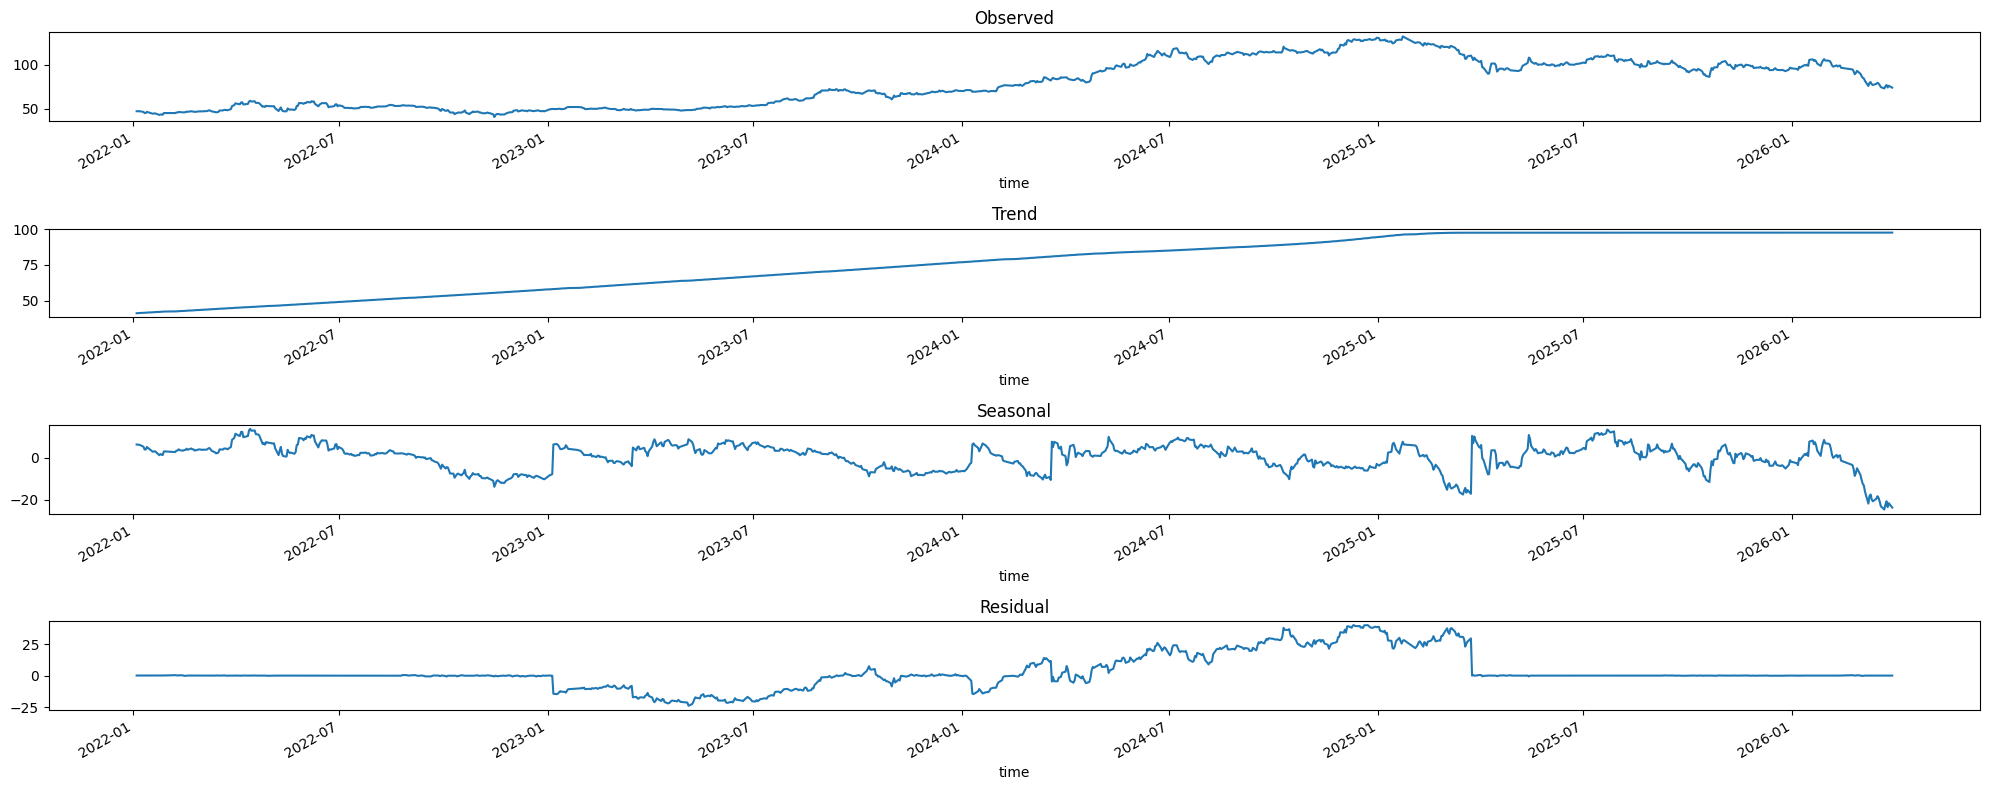

In [ ]:
df_close = df[['time', 'close']].copy()
df_close = df_close.set_index('time')

stl = STL(df_close['close'], period=252, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(20, 8))
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [ ]:
df['EMA_9'] = df['close'].ewm(span=9).mean().shift()
df['SMA_5'] = df['close'].rolling(5).mean().shift()
df['SMA_10'] = df['close'].rolling(10).mean().shift()
df['SMA_15'] = df['close'].rolling(15).mean().shift()
df['SMA_30'] = df['close'].rolling(30).mean().shift()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.time, y=df.EMA_9, name='EMA 9'))
fig.add_trace(go.Scatter(x=df.time, y=df.SMA_5, name='SMA 5'))
fig.add_trace(go.Scatter(x=df.time, y=df.SMA_10, name='SMA 10'))
fig.add_trace(go.Scatter(x=df.time, y=df.SMA_15, name='SMA 15'))
fig.add_trace(go.Scatter(x=df.time, y=df.SMA_30, name='SMA 30'))
fig.add_trace(go.Scatter(x=df.time, y=df.close, name='close', opacity=0.2))
fig.show()

In [ ]:
def relative_strength_idx(df, n=14):
    close = df['close']
    delta = close.diff()
    delta = delta[1:]
    pricesUp = delta.copy()
    pricesDown = delta.copy()
    pricesUp[pricesUp < 0] = 0
    pricesDown[pricesDown > 0] = 0
    rollUp = pricesUp.rolling(n).mean()
    rollDown = pricesDown.abs().rolling(n).mean()
    rs = rollUp / rollDown
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

df['RSI'] = relative_strength_idx(df).fillna(0)

fig = go.Figure(go.Scatter(x=df.time, y=df.RSI, name='RSI'))
fig.show()

In [ ]:
EMA_12 = pd.Series(df['close'].ewm(span=12, min_periods=12).mean())
EMA_26 = pd.Series(df['close'].ewm(span=26, min_periods=26).mean())
df['MACD'] = pd.Series(EMA_12 - EMA_26)
df['MACD_signal'] = pd.Series(df.MACD.ewm(span=9, min_periods=9).mean())

fig = make_subplots(rows=2, cols=1)
fig.add_trace(go.Scatter(x=df.time, y=df.close, name='close'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.time, y=EMA_12, name='EMA 12'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.time, y=EMA_26, name='EMA 26'), row=1, col=1)
fig.add_trace(go.Scatter(x=df.time, y=df['MACD'], name='MACD'), row=2, col=1)
fig.add_trace(go.Scatter(x=df.time, y=df['MACD_signal'], name='Signal line'), row=2, col=1)
fig.show()

In [ ]:
df['close'] = df['close'].shift(-1)

df = df.iloc[33:] # Because of moving averages and MACD line
df = df[:-1]      # Because of shifting close price

df.index = range(len(df))

In [ ]:
test_size  = 0.15
valid_size = 0.15

test_split_idx  = int(df.shape[0] * (1 - test_size))
valid_split_idx = int(df.shape[0] * (1 - (valid_size + test_size)))

train_df = df.loc[:valid_split_idx].copy()
valid_df = df.loc[valid_split_idx+1:test_split_idx].copy()
test_df  = df.loc[test_split_idx+1:].copy()

fig = go.Figure()
fig.add_trace(go.Scatter(x=train_df.time, y=train_df.close, name='Training'))
fig.add_trace(go.Scatter(x=valid_df.time, y=valid_df.close, name='Validation'))
fig.add_trace(go.Scatter(x=test_df.time,  y=test_df.close,  name='Test'))
fig.show()

In [ ]:
drop_cols = ['time', 'volume', 'open', 'low', 'high']

train_df = train_df.drop(columns=drop_cols)
valid_df = valid_df.drop(columns=drop_cols)
test_df  = test_df.drop(columns=drop_cols)

In [ ]:
y_train = train_df['close'].copy()
X_train = train_df.drop(columns=['close'])

y_valid = valid_df['close'].copy()
X_valid = valid_df.drop(columns=['close'])

y_test  = test_df['close'].copy()
X_test  = test_df.drop(columns=['close'])

X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   EMA_9        714 non-null    float64
 1   SMA_5        714 non-null    float64
 2   SMA_10       714 non-null    float64
 3   SMA_15       714 non-null    float64
 4   SMA_30       714 non-null    float64
 5   RSI          714 non-null    float64
 6   MACD         714 non-null    float64
 7   MACD_signal  714 non-null    float64
dtypes: float64(8)
memory usage: 44.8 KB


In [ ]:
%%time
tscv = TimeSeriesSplit(n_splits=5)

# Khởi tạo XGBRegressor
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42
)

parameters = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'gamma': [0, 0.1, 0.2]
}

clf = GridSearchCV(
    model,
    parameters,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

clf.fit(X_train, y_train)

print(f'Best params: {clf.best_params_}')
print(f'Best validation score = {clf.best_score_}')

Best params: {'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best validation score = -9.538632584904414
CPU times: user 1.65 s, sys: 88.3 ms, total: 1.74 s
Wall time: 1min 15s


In [ ]:
# Khởi tạo XGBoost với các tham số tốt nhất từ GridSearch
model = xgb.XGBRegressor(
    **clf.best_params_,
    objective='reg:squarederror',
    random_state=42
)

# Huấn luyện mô hình
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

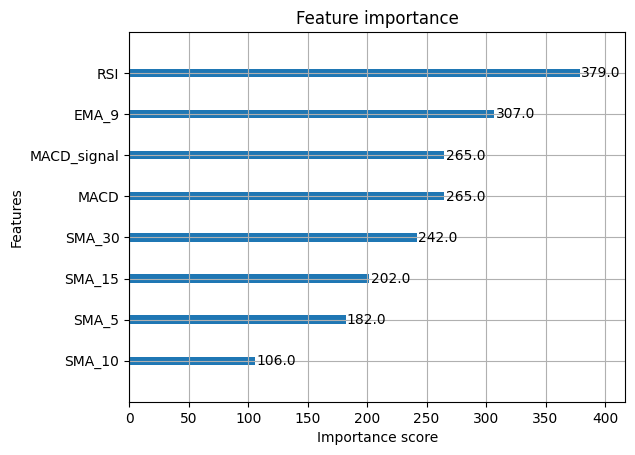

In [ ]:
plot_importance(model);

In [ ]:
y_pred = model.predict(X_test)
print(f'y_true = {np.array(y_test)[:5]}')
print(f'y_pred = {y_pred[:5]}')

print(f'mean_squared_error = {mean_squared_error(y_test, y_pred)}')

y_true = [ 99.46  99.27  96.69 100.65  97.98]
y_pred = [103.79631  104.63237  105.118065 105.74224  103.21916 ]
mean_squared_error = 29.998197816934802


In [ ]:
predicted_prices = df.loc[test_split_idx+1:].copy()

predicted_prices['y_pred'] = y_pred
predicted_prices['y_true'] = y_test.values

fig = make_subplots(rows=2, cols=1)

fig.add_trace(go.Scatter(
    x=df.time,
    y=df.close,
    name='Truth',
    marker_color='LightSkyBlue'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=predicted_prices.time,
    y=predicted_prices['y_pred'],
    name='Prediction',
    marker_color='MediumPurple'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=predicted_prices.time,
    y=predicted_prices['y_true'],
    name='Truth',
    marker_color='LightSkyBlue',
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=predicted_prices.time,
    y=predicted_prices['y_pred'],
    name='Prediction',
    marker_color='MediumPurple',
    showlegend=False
), row=2, col=1)

fig.show()


In [ ]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f'Mean Absolute Percentage Error (MAPE) = {mape:.4f}')

Mean Absolute Percentage Error (MAPE) = 0.0504
